In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve
)

RANDOM_STATE = 42
FLAG_QUANTILE = 0.85
CATEGORY = "Games"
RESULTS_DIR = "results_Games"
os.makedirs(RESULTS_DIR, exist_ok=True)
pd.set_option("display.max_rows", 20)

In [39]:
df = pd.read_csv('/Users/riddhiagrawal/Downloads/Android_Permission.csv')
df.shape

(29999, 184)

In [40]:
df["Category"].value_counts()

Category
Entertainment        2827
Travel & Local       2154
Arcade & Action      1959
Books & Reference    1959
Brain & Puzzle       1873
                     ... 
Sports Games          341
Photography           297
Racing                288
Medical               270
Weather               173
Name: count, Length: 30, dtype: int64

In [41]:
BROAD_CATEGORY_MAP = {
    "Arcade & Action": "Games", "Brain & Puzzle": "Games", "Casual": "Games",
    "Cards & Casino": "Games", "Sports Games": "Games", "Racing": "Games",
    "Social": "Social & Communication", "Communication": "Social & Communication",
    "News & Magazines": "Social & Communication",
    "Tools": "Productivity & Tools", "Business": "Productivity & Tools",
    "Finance": "Productivity & Tools", "Productivity": "Productivity & Tools",
    "Libraries & Demo": "Productivity & Tools",
    "Entertainment": "Entertainment & Media", "Media & Video": "Entertainment & Media",
    "Music & Audio": "Entertainment & Media", "Comics": "Entertainment & Media",
    "Photography": "Entertainment & Media",
    "Education": "Education & Reference", "Books & Reference": "Education & Reference",
    "Travel & Local": "Lifestyle & Health", "Personalization": "Lifestyle & Health",
    "Lifestyle": "Lifestyle & Health", "Health & Fitness": "Lifestyle & Health",
    "Sports": "Lifestyle & Health", "Transportation": "Lifestyle & Health",
    "Shopping": "Lifestyle & Health", "Medical": "Lifestyle & Health",
    "Weather": "Lifestyle & Health",
}
df["BroadCategory"] = df["Category"].map(BROAD_CATEGORY_MAP)
df["BroadCategory"].value_counts()

/var/folders/l3/prgs2yv141j1p08v_74rp_jw0000gn/T/ipykernel_93250/793609967.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["BroadCategory"] = df["Category"].map(BROAD_CATEGORY_MAP)


BroadCategory
Lifestyle & Health        8064
Games                     7020
Entertainment & Media     5044
Productivity & Tools      4625
Education & Reference     3264
Social & Communication    1982
Name: count, dtype: int64

In [42]:
df = df.drop_duplicates().reset_index(drop=True)
df.shape

(27310, 185)

In [43]:
PERMISSION_COLUMN_MAP = {
    "Camera": ["Hardware controls : take pictures and videos (D)"],
    "Location": [
        "Your location : coarse (network-based) location (D)",
        "Your location : fine (GPS) location (D)",
        "Default : coarse (network-based) location (S)",
    ],
    "Contacts": [
        "Your personal information : read contact data (D)",
        "Your personal information : write contact data (D)",
        "Default : write contact data (S)",
        "Your accounts : contacts data in Google accounts (D)",
    ],
    "Microphone": ["Hardware controls : record audio (D)"],
    "Storage": [
        "Storage : modify/delete USB storage contents modify/delete SD card contents (D)",
        "Default : modify/delete USB storage contents modify/delete SD card contents (S)",
    ],
    "SMS": [
        "Services that cost you money : send SMS messages (D)",
        "Your messages : edit SMS or MMS (D)", "Your messages : read SMS or MMS (D)",
        "Your messages : receive SMS (D)", "Your messages : receive MMS (D)",
        "Your messages : send SMS-received broadcast (S)",
    ],
    "CallLogs": [],
    "Bluetooth": [
        "Network communication : create Bluetooth connections (D)",
        "System tools : bluetooth administration (D)",
    ],
    "Calendar": [
        "Your personal information : add or modify calendar events and send email to guests (D)",
        "Your personal information : read calendar events (D)",
    ],
    "PhoneState": [
        "Default : read phone state and identity (S)",
        "Phone calls : read phone state and identity (D)",],
    "Internet": [
        "Default : full Internet access (S)",
        "Network communication : full Internet access (D)",
    ],
    "ReadPhoneNumbers": [],
}
PERMISSIONS = list(PERMISSION_COLUMN_MAP.keys())

perm_cols = {}
for target, sources in PERMISSION_COLUMN_MAP.items():
    valid = [c for c in sources if c in df.columns]
    perm_cols[target] = (df[valid].fillna(0).sum(axis=1) > 0).astype(int) if valid else pd.Series(0, index=df.index)
df = pd.concat([df, pd.DataFrame(perm_cols)], axis=1)

pd.Series({p: len(c) for p, c in PERMISSION_COLUMN_MAP.items()}, name="source_columns_used")

Camera              1
Location            3
Contacts            4
Microphone          1
Storage             2
SMS                 6
CallLogs            0
Bluetooth           2
Calendar            2
PhoneState          2
Internet            2
ReadPhoneNumbers    0
Name: source_columns_used, dtype: int64

In [44]:
CATEGORY = "Games"   # change this per notebook

df_cat = df[df["BroadCategory"] == CATEGORY].copy()
print(f"{CATEGORY}: {df_cat.shape[0]} rows")
print(df_cat["Class"].value_counts())

Games: 6092 rows
Class
1    3633
0    2459
Name: count, dtype: int64


In [54]:
# The 12 grouped permission features (drop the 2 useless all-zero ones)
grouped_perm_cols = ["Camera", "Location", "Contacts", "Microphone", "Storage",
                      "SMS", "Bluetooth", "Calendar", "PhoneState", "Internet"]

# Numeric metadata features
numeric_cols = ["Rating", "Number of ratings", "Price",
                 "Dangerous permissions count", "Safe permissions count"]

feature_cols = grouped_perm_cols + numeric_cols

X = df_cat[feature_cols].copy()
y = df_cat["Class"].copy()

print("Feature shape:", X.shape)
X.head()

Feature shape: (7416, 15)


,Camera,Location,Contacts,Microphone,Storage,SMS,Bluetooth,Calendar,PhoneState,Internet,Rating,Number of ratings,Price,Dangerous permissions count,Safe permissions count
4,0,0,0,0,0,0,0,0,0,1,0.0,0,5.99,1.0,0
5,0,0,0,0,1,0,0,0,0,1,4.5,16,0.00,3.0,1
11,0,0,0,0,0,0,0,0,1,0,4.1,67,0.00,1.0,0
29,1,0,0,0,0,0,0,0,0,1,3.1,181,0.00,2.0,0
33,0,1,0,0,1,0,0,0,0,1,5.0,2,0.00,3.0,0


In [55]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (5932, 15) Test: (1484, 15)


In [47]:
X.isnull().sum()[X.isnull().sum() > 0]

Dangerous permissions count    12
dtype: int64

In [48]:
X = X.fillna(X.median(numeric_only=True))
print("Remaining NaNs:", X.isnull().sum().sum())

Remaining NaNs: 0


In [49]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (4873, 15) Test: (1219, 15)


In [50]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(random_state=RANDOM_STATE),
    "SVM": SVC(random_state=RANDOM_STATE),
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Accuracy": accuracy_score(y_test, y_pred),
    })

results_df = pd.DataFrame(results)
print(f"Category: {CATEGORY}")
results_df

Category: Games


,Model,Precision,Recall,F1,Accuracy
0,Decision Tree,0.668892,0.689133,0.678862,0.611157
1,Random Forest,0.687173,0.722146,0.704225,0.638228
2,AdaBoost,0.823091,0.607978,0.699367,0.688269
3,SVM,0.720290,0.683631,0.701482,0.652994


In [32]:
results_df.to_csv('results_Games.csv', index=False)

In [52]:
CATEGORY = "Lifestyle & Health"

In [76]:
df_cat = df[df["BroadCategory"] == CATEGORY].copy()
print(f"{CATEGORY}: {df_cat.shape[0]} rows")
print(df_cat["Class"].value_counts())

Education & Reference: 3099 rows
Class
1    2076
0    1023
Name: count, dtype: int64


In [77]:
grouped_perm_cols = ["Camera", "Location", "Contacts", "Microphone", "Storage",
                      "SMS", "Bluetooth", "Calendar", "PhoneState", "Internet"]

numeric_cols = ["Rating", "Number of ratings", "Price",
                 "Dangerous permissions count", "Safe permissions count"]

feature_cols = grouped_perm_cols + numeric_cols

X = df_cat[feature_cols].copy()
y = df_cat["Class"].copy()

X = X.fillna(X.median(numeric_only=True))
print("Feature shape:", X.shape, "| Remaining NaNs:", X.isnull().sum().sum())

Feature shape: (3099, 15) | Remaining NaNs: 0


In [78]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (2479, 15) Test: (620, 15)


In [79]:
print("CATEGORY:", CATEGORY)
print("df_cat rows:", df_cat.shape[0])
print("y value counts:\n", y.value_counts())

CATEGORY: Education & Reference
df_cat rows: 3099
y value counts:
 Class
1    2076
0    1023
Name: count, dtype: int64


In [59]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(random_state=RANDOM_STATE),
    "SVM": SVC(random_state=RANDOM_STATE),
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Accuracy": accuracy_score(y_test, y_pred),
    })

results_df = pd.DataFrame(results)
print(f"Category: {CATEGORY}")
results_df

Category: Lifestyle & Health


,Model,Precision,Recall,F1,Accuracy
0,Decision Tree,0.852641,0.862931,0.857755,0.776280
1,Random Forest,0.857259,0.906034,0.880972,0.808625
2,AdaBoost,0.870173,0.912931,0.891039,0.825472
3,SVM,0.785326,0.996552,0.878419,0.784367


In [60]:
results_df.to_csv('results_Lifestyle_Health.csv', index=False)

In [61]:
CATEGORY = "Entertainment & Media"

In [62]:
df_cat = df[df["BroadCategory"] == CATEGORY].copy()
print(f"{CATEGORY}: {df_cat.shape[0]} rows")
print(df_cat["Class"].value_counts())

Entertainment & Media: 4659 rows
Class
1    3112
0    1547
Name: count, dtype: int64


In [66]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(random_state=RANDOM_STATE),
    "SVM": SVC(random_state=RANDOM_STATE),
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Accuracy": accuracy_score(y_test, y_pred),
    })

results_df = pd.DataFrame(results)
print(f"Category: {CATEGORY}")
results_df

Category: Entertainment & Media


,Model,Precision,Recall,F1,Accuracy
0,Decision Tree,0.768595,0.746388,0.757329,0.680258
1,Random Forest,0.778831,0.791332,0.785032,0.710300
2,AdaBoost,0.834646,0.680578,0.749779,0.696352
3,SVM,0.700118,0.951846,0.806803,0.695279


In [67]:
results_df.to_csv('results_Entertainment_Media.csv', index=False)

In [68]:
CATEGORY = "Productivity & Tools"

In [73]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(random_state=RANDOM_STATE),
    "SVM": SVC(random_state=RANDOM_STATE),
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Accuracy": accuracy_score(y_test, y_pred),
    })

results_df = pd.DataFrame(results)
print(f"Category: {CATEGORY}")
results_df

Category: Productivity & Tools


,Model,Precision,Recall,F1,Accuracy
0,Decision Tree,0.632735,0.635271,0.634000,0.573427
1,Random Forest,0.667961,0.689379,0.678501,0.620047
2,AdaBoost,0.725641,0.567134,0.636670,0.623543
3,SVM,0.638983,0.755511,0.692378,0.609557


In [74]:
results_df.to_csv('results_Productivity_Tools.csv', index=False)

In [75]:
CATEGORY = "Education & Reference"

In [88]:
df_cat = df[df["BroadCategory"] == CATEGORY].copy()
print(f"{CATEGORY}: {df_cat.shape[0]} rows")
print(df_cat["Class"].value_counts())

Social & Communication: 1756 rows
Class
1    1121
0     635
Name: count, dtype: int64


In [89]:
grouped_perm_cols = ["Camera", "Location", "Contacts", "Microphone", "Storage",
                      "SMS", "Bluetooth", "Calendar", "PhoneState", "Internet"]

numeric_cols = ["Rating", "Number of ratings", "Price",
                 "Dangerous permissions count", "Safe permissions count"]

feature_cols = grouped_perm_cols + numeric_cols

X = df_cat[feature_cols].copy()
y = df_cat["Class"].copy()

X = X.fillna(X.median(numeric_only=True))
print("Feature shape:", X.shape, "| Remaining NaNs:", X.isnull().sum().sum())

Feature shape: (1756, 15) | Remaining NaNs: 0


In [90]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (1404, 15) Test: (352, 15)


In [91]:
print("CATEGORY:", CATEGORY)
print("df_cat rows:", df_cat.shape[0])
print("y value counts:\n", y.value_counts())

CATEGORY: Social & Communication
df_cat rows: 1756
y value counts:
 Class
1    1121
0     635
Name: count, dtype: int64


In [85]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(random_state=RANDOM_STATE),
    "SVM": SVC(random_state=RANDOM_STATE),
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Accuracy": accuracy_score(y_test, y_pred),
    })

results_df = pd.DataFrame(results)
print(f"Category: {CATEGORY}")
results_df

Category: Education & Reference


,Model,Precision,Recall,F1,Accuracy
0,Decision Tree,0.819672,0.843373,0.831354,0.770968
1,Random Forest,0.857488,0.855422,0.856454,0.808065
2,AdaBoost,0.960366,0.759036,0.847914,0.817742
3,SVM,0.798982,0.756627,0.777228,0.709677


In [86]:
results_df.to_csv('results_Education_Reference.csv', index=False)

In [87]:
CATEGORY = "Social & Communication"

In [92]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(random_state=RANDOM_STATE),
    "SVM": SVC(random_state=RANDOM_STATE),
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Accuracy": accuracy_score(y_test, y_pred),
    })

results_df = pd.DataFrame(results)
print(f"Category: {CATEGORY}")
results_df

Category: Social & Communication


,Model,Precision,Recall,F1,Accuracy
0,Decision Tree,0.756757,0.746667,0.751678,0.684659
1,Random Forest,0.770270,0.760000,0.765101,0.701705
2,AdaBoost,0.870968,0.720000,0.788321,0.752841
3,SVM,0.715415,0.804444,0.757322,0.670455


In [93]:
results_df.to_csv('results_Social_Communication.csv', index=False)

In [96]:
import pandas as pd

categories = ["Games", "Lifestyle_Health", "Entertainment_Media",
              "Productivity_Tools", "Education_Reference", "Social_Communication"]

for cat in categories:
    df_result = pd.read_csv(f'/Users/riddhiagrawal/results_{cat}.csv')
    print(f"\n=== {cat} ===")
    print(df_result)


=== Games ===
           Model  Precision    Recall        F1  Accuracy
0  Decision Tree   0.668892  0.689133  0.678862  0.611157
1  Random Forest   0.687173  0.722146  0.704225  0.638228
2       AdaBoost   0.823091  0.607978  0.699367  0.688269
3            SVM   0.720290  0.683631  0.701482  0.652994

=== Lifestyle_Health ===
           Model  Precision    Recall        F1  Accuracy
0  Decision Tree   0.852641  0.862931  0.857755  0.776280
1  Random Forest   0.857259  0.906034  0.880972  0.808625
2       AdaBoost   0.870173  0.912931  0.891039  0.825472
3            SVM   0.785326  0.996552  0.878419  0.784367

=== Entertainment_Media ===
           Model  Precision    Recall        F1  Accuracy
0  Decision Tree   0.768595  0.746388  0.757329  0.680258
1  Random Forest   0.778831  0.791332  0.785032  0.710300
2       AdaBoost   0.834646  0.680578  0.749779  0.696352
3            SVM   0.700118  0.951846  0.806803  0.695279

=== Productivity_Tools ===
           Model  Precision    R

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

categories = ["Games", "Lifestyle_Health", "Entertainment_Media",
              "Productivity_Tools", "Education_Reference", "Social_Communication"]

# Load all 6 results and combine into one dataframe
all_results = []
for cat in categories:
    df_result = pd.read_csv(f'/Users/riddhiagrawal/results_{cat}.csv')
    df_result["Category"] = cat.replace("_", " & ", 1) if cat != "Games" else cat
    all_results.append(df_result)

combined = pd.concat(all_results, ignore_index=True)
print(combined)

            Model  Precision    Recall        F1  Accuracy  \
0   Decision Tree   0.668892  0.689133  0.678862  0.611157   
1   Random Forest   0.687173  0.722146  0.704225  0.638228   
2        AdaBoost   0.823091  0.607978  0.699367  0.688269   
3             SVM   0.720290  0.683631  0.701482  0.652994   
4   Decision Tree   0.852641  0.862931  0.857755  0.776280   
5   Random Forest   0.857259  0.906034  0.880972  0.808625   
6        AdaBoost   0.870173  0.912931  0.891039  0.825472   
7             SVM   0.785326  0.996552  0.878419  0.784367   
8   Decision Tree   0.768595  0.746388  0.757329  0.680258   
9   Random Forest   0.778831  0.791332  0.785032  0.710300   
10       AdaBoost   0.834646  0.680578  0.749779  0.696352   
11            SVM   0.700118  0.951846  0.806803  0.695279   
12  Decision Tree   0.632735  0.635271  0.634000  0.573427   
13  Random Forest   0.667961  0.689379  0.678501  0.620047   
14       AdaBoost   0.725641  0.567134  0.636670  0.623543   
15      

In [5]:
import pandas as pd

categories = ["Games", "Lifestyle_Health", "Entertainment_Media",
              "Productivity_Tools", "Education_Reference", "Social_Communication"]

all_results = []
for cat in categories:
    df_result = pd.read_csv(f'/Users/riddhiagrawal/results_{cat}.csv')
    df_result["Category"] = cat.replace("_", " & ", 1) if cat != "Games" else cat
    all_results.append(df_result)

final_results = pd.concat(all_results, ignore_index=True)

# Reorder columns so Category comes first
cols = ["Category"] + [c for c in final_results.columns if c != "Category"]
final_results = final_results[cols]

final_results.to_csv('/Users/riddhiagrawal/final_results_android.csv', index=False)
print("Saved! Shape:", final_results.shape)
final_results

Saved! Shape: (24, 6)


,Category,Model,Precision,Recall,F1,Accuracy
0,Games,Decision Tree,0.668892,0.689133,0.678862,0.611157
1,Games,Random Forest,0.687173,0.722146,0.704225,0.638228
2,Games,AdaBoost,0.823091,0.607978,0.699367,0.688269
3,Games,SVM,0.720290,0.683631,0.701482,0.652994
4,Lifestyle & Health,Decision Tree,0.852641,0.862931,0.857755,0.776280
5,Lifestyle & Health,Random Forest,0.857259,0.906034,0.880972,0.808625
6,Lifestyle & Health,AdaBoost,0.870173,0.912931,0.891039,0.825472
7,Lifestyle & Health,SVM,0.785326,0.996552,0.878419,0.784367
8,Entertainment & Media,Decision Tree,0.768595,0.746388,0.757329,0.680258
9,Entertainment & Media,Random Forest,0.778831,0.791332,0.785032,0.710300


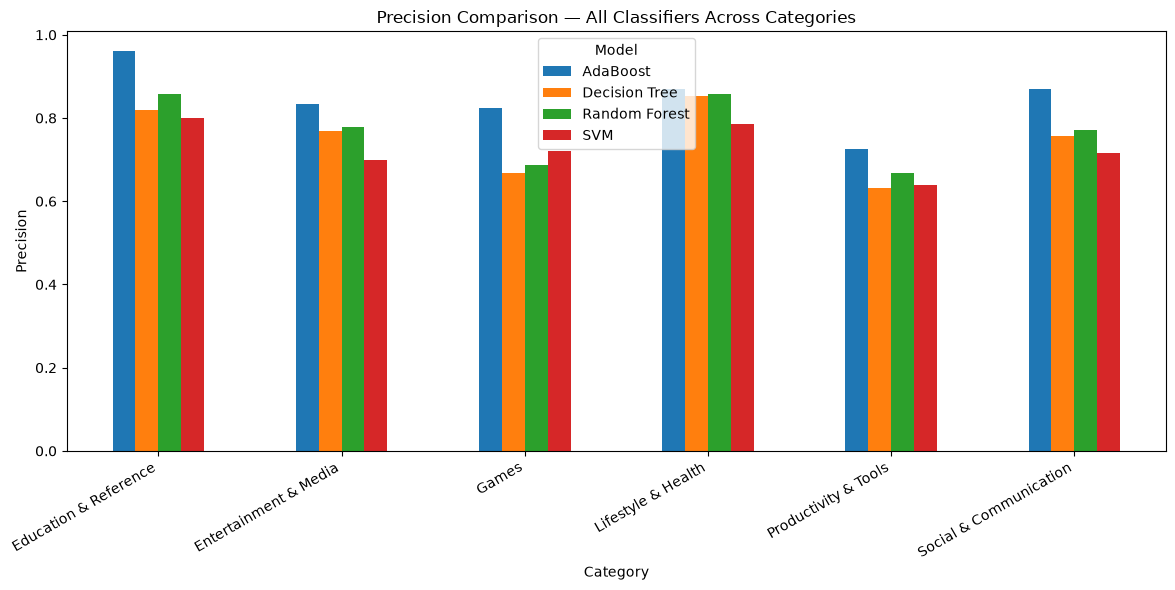

In [2]:
pivot = combined.pivot(index="Category", columns="Model", values="Precision")

pivot.plot(kind="bar", figsize=(12, 6))
plt.title("Precision Comparison — All Classifiers Across Categories")
plt.ylabel("Precision")
plt.xlabel("Category")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Model")
plt.tight_layout()
plt.savefig('/Users/riddhiagrawal/precision_comparison_all_categories.png', dpi=150)
plt.show()